**Nettoyer la mémoire**

In [250]:
### -*-coding:Latin-1 -*
def clearall():
    all = [var for var in globals() if var[0] != "_"]
    for var in all:
        del globals()[var]
        
clearall()

**Librairies**

In [251]:
###Library
import numpy as np
import matplotlib.pyplot as plt
from math import *
import scipy
import scipy.stats
import time 

plt.close("all")

**Paramètres physiques**

In [252]:
######################
hbar=1.0546e-34
c=2.997e8
q=1.60217653e-19 
temp=300
kappa=1.3806622e-23
Nq=3

In [253]:
#####################
UT=kappa*temp/q
beta_m=1/(UT*q) 

**Levels quantum**

In [254]:
#####################
Omega_gap=1.18e15
Omegap=Omega_gap*np.array([-1.0,0.0,3.0])

Ep=hbar*np.diag(Omegap)
Energ=-np.diag([Omegap[0]-Omegap[1],Omegap[0]-Omegap[2],Omegap[1]-Omegap[2]])

**Pauli relaxation**

In [255]:
##############
Gam=-1.e10
Dg=-np.diag([Gam]*3)


#######################
#####
W21=W31=2.e11
W32=1.e11

#######################
#####
WW=np.array([W21,W31,W32])
a=np.exp(beta_m*Omegap*hbar)
#######################
#####
W=np.zeros((Nq,Nq))
for j in range(1,Nq):
    for k in range(0,j):
        W[k,j]=WW[j-1+k]
        W[j,k]=W[k,j]*a[k]/a[j]
for j in range(Nq):
    W[j,j]=-sum(W[:,j])

**Electromagnetic field**

In [256]:
E0=4.2186e9
####
#####################
M=np.array([9.1e-29,9.1e-29,9.1e-29])
Minf=max(abs(M))

#####################
Energ_Rabi=E0*Minf

**Coulomb parameters**

In [257]:
R=1.e-24
####
R0=-np.diag([0,2*R,2*R])/hbar
###

**Numerical paramaeters**

In [258]:
###Temps adimensionné
Nt=100000
dt=1

#####################
Omeg_Rabi=E0*Minf/hbar

**Initial density**

In [259]:
Uinit=np.array([[0,0,1]+[0]*6]).T
Uinit

array([[0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [260]:
R

1e-24

**Matrix**

In [275]:
def AL(sol):
    resu=np.zeros((9,9))
    ####Add free energies + Coulomb linear
    resu[3:6,6:]=-(Energ+R0)/Omeg_Rabi
    resu[6:,3:6]=(Energ+R0)/Omeg_Rabi
    ####Add relaxation in coherences
    resu[3:6,3:6]=Dg/Omeg_Rabi
    resu[6:,6:]=Dg/Omeg_Rabi
    ####Add relaxation in populations
    resu[:3,:3]=W/Omeg_Rabi

    return resu@sol

def AN(sol):
    resu=np.zeros((9,9))
    ###RC_1
    resu[:3,3:6]=2*np.concatenate((np.zeros((3,2)),np.array([[R*sol[7,0],\
                                                              -R*sol[7,0],0]]).T),axis=1)/hbar
    ###RC_2
    resu[:3,6:]=2*np.concatenate((np.array([[R*sol[2,0],-R*sol[2,0],0]]).T,\
                                 np.zeros((3,1)),\
                                  np.array([[-R*sol[5,0],R*sol[5,0],0]]).T),axis=1)/hbar
    ###RC_3
    resu[3:6,:3]=np.concatenate((np.array([[0,R*sol[8,0],-R*sol[8,0]]]).T,\
                                np.array([[0,-R*sol[7,0],R*sol[7,0]]]).T,\
                                 np.zeros((3,1))),axis=1)/hbar
    ###RC_4
    resu[3:6,3:6]=np.concatenate((np.array([[0,-R*sol[7,0],0]]).T,\
                                np.array([[0,0,-R*sol[6,0]]]).T,\
                                 np.array([[0,R*sol[6,0],-R*sol[6,0]]]).T),axis=1)/hbar
    ###RC_5
    #resu[3:6,6:]=np.concatenate((np.array([[sol[2,0],R*sol[4,0],0]]).T,\
    #                            np.array([[-sol[5,0],0,R*sol[3,0]]]).T,\
    #                             np.array([[sol[4,0],R*sol[3,0],-R*sol[3,0]]]).T),axis=1)/hbar
    ###RC_6
    resu[6:,:3]=np.concatenate((np.array([[R*sol[2,0],-R*sol[5,0],R*sol[5,0]]]).T,\
                                np.array([[-R*sol[2,0],R*sol[4,0],-R*sol[4,0]]]).T,\
                                 np.zeros((3,1))),axis=1)/hbar
    ###RC_7
    resu[6:,3:6]=np.concatenate((np.zeros((3,1)),\
                                np.array([[-R*sol[4,0],R*sol[3,0],-R*sol[3,0]]]).T,\
                                 np.array([[R*sol[5,0],-R*sol[3,0],R*sol[3,0]]]).T),axis=1)/hbar
    ###RC_8
    resu[6:,6:]=np.concatenate((np.zeros((3,1)),\
                                np.array([[-R*sol[7,0],R*sol[6,0],-R*sol[6,0]]]).T,\
                                 np.array([[R*sol[8,0],R*sol[6,0],-R*sol[6,0]]]).T),axis=1)/hbar

    resu=resu/Omeg_Rabi
    print(resu[1,:])
    return resu@sol

def Af(sol):
    return AL(sol)+AN(sol)
    

In [276]:
AN(Uinit)

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -5.20979045e-06  0.00000000e+00
  0.00000000e+00]


array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

**Functions**

In [262]:
def sol_RK4(dtime,Ntime):
    sol=Uinit
    tab_sol=np.zeros((9,Ntime))
    tab_sol[:,0]=sol[:,0]
    for t in range(1,Ntime):
        ####
        R1=sol+dtime*Af(sol)/2
        R2=sol+dtime*Af(R1)/2
        R3=sol+dtime*Af(R2)
        #####
        sol=sol+dtime*(Af(sol)+2*Af(R1)+2*Af(R2)+Af(R3))/6
        tab_sol[:,t]=sol[:,0]
    
    
    return tab_sol

In [263]:
SOL=sol_RK4(dt,Nt)

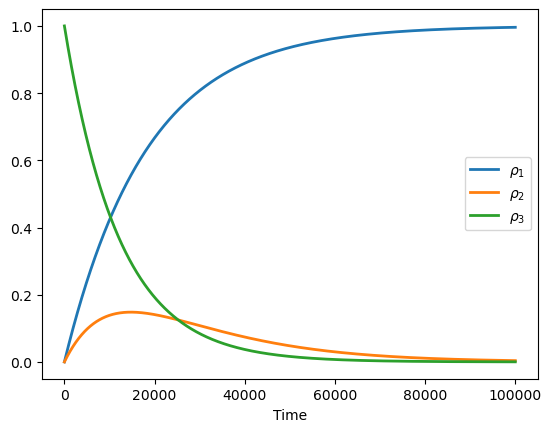

In [264]:
plt.figure()
plt.plot(SOL[0,:],lw=2,label=r'$\rho_1$')
plt.plot(SOL[1,:],lw=2,label=r'$\rho_2$')
plt.plot(SOL[2,:],lw=2,label=r'$\rho_3$')
plt.legend()
plt.xlabel('Time')
plt.show()

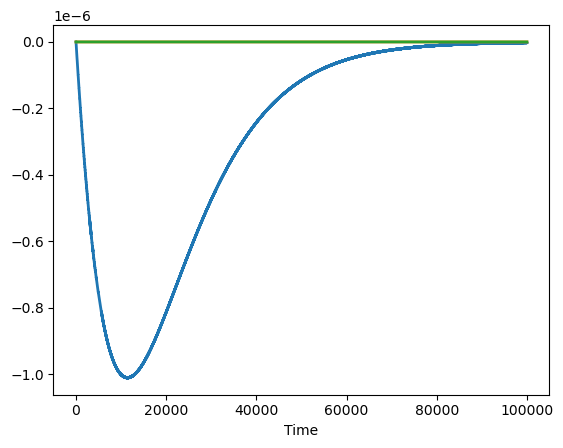

In [267]:
plt.figure()
plt.plot(SOL[3,:],lw=2)
plt.plot(SOL[4,:],lw=2)
plt.plot(SOL[5,:],lw=2)
#plt.legend()
plt.xlabel('Time')
plt.show()

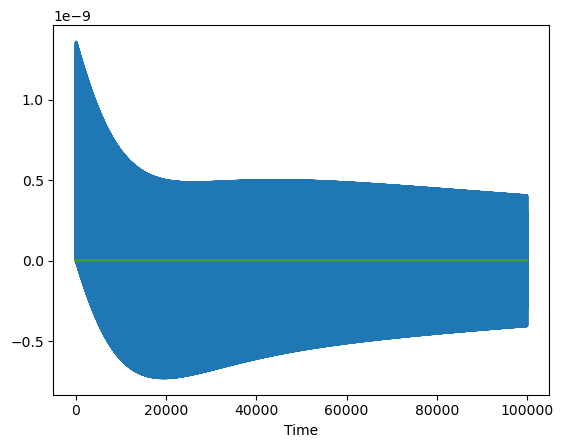

In [268]:
plt.figure()
plt.plot(SOL[6,:],lw=2)
plt.plot(SOL[7,:],lw=2)
plt.plot(SOL[8,:],lw=2)
#plt.legend()
plt.xlabel('Time')
plt.show()